In [1]:
# DAY 32 - BUILDING A PERSONALIZED PRODUCT RECOMMENDATION ENGINE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

print("Day 32 libraries imported successfully!")

Day 32 libraries imported successfully!


In [2]:
# Load the cleaned Sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Sales dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nImportant columns:")
print([
    "customer_name",
    "product_name",
    "category",
    "sub_category",
    "quantity",
    "sales"
])

df.head()

Sales dataset loaded successfully!
Dataset shape: (51290, 23)

Important columns:
['customer_name', 'product_name', 'category', 'sub_category', 'quantity', 'sales']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Create customer-product purchase matrix

customer_product_matrix = df.pivot_table(
    index="customer_name",
    columns="product_name",
    values="quantity",
    aggfunc="sum",
    fill_value=0
)

print("Customer-product matrix created successfully!")

print("Matrix shape:", customer_product_matrix.shape)

print("\nFirst 5 customers:")
display(customer_product_matrix.head())

Customer-product matrix created successfully!
Matrix shape: (795, 3788)

First 5 customers:


product_name,"""While you Were Out"" Message Book, One Form per Page","#10 Gummed Flap White Envelopes, 100/Box",#10 Self-Seal White Envelopes,"#10 White Business Envelopes,4 1/8 x 9 1/2","#10- 4 1/8"" x 9 1/2"" Recycled Envelopes","#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes","#10-4 1/8"" x 9 1/2"" Premium Diagonal Seam Envelopes",#6 3/4 Gummed Flap White Envelopes,"1.7 Cubic Foot Compact ""Cube"" Office Refrigerators","1/4 Fold Party Design Invitations & White Envelopes, 24 8-1/2"" X 11"" Cards, 25 Env./Pack",...,Zebra ZM400 Thermal Label Printer,Zebra Zazzle Fluorescent Highlighters,Zipper Ring Binder Pockets,i.Sound Portable Power - 8000 mAh,iHome FM Clock Radio with Lightning Dock,"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",iOttie HLCRIO102 Car Mount,iOttie XL Car Mount,invisibleSHIELD by ZAGG Smudge-Free Screen Protector,netTALK DUO VoIP Telephone Service
customer_name,,,,,,,,,,,,,,,,,,,,,
Aaron Bergman,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aaron Hawkins,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aaron Smayling,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adam Bellavance,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adam Hart,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Calculate customer similarity

customer_similarity = cosine_similarity(
    customer_product_matrix
)

customer_similarity_df = pd.DataFrame(
    customer_similarity,
    index=customer_product_matrix.index,
    columns=customer_product_matrix.index
)

print("Customer similarity calculated successfully!")

print("Similarity matrix shape:", customer_similarity_df.shape)

print("\nFirst 5 customers:")
display(customer_similarity_df.iloc[:5, :5])

Customer similarity calculated successfully!
Similarity matrix shape: (795, 795)

First 5 customers:


customer_name,Aaron Bergman,Aaron Hawkins,Aaron Smayling,Adam Bellavance,Adam Hart
customer_name,,,,,
Aaron Bergman,1.000000,0.018327,0.039146,0.029796,0.017848
Aaron Hawkins,0.018327,1.000000,0.017548,0.017300,0.005979
Aaron Smayling,0.039146,0.017548,1.000000,0.008302,0.039123
Adam Bellavance,0.029796,0.017300,0.008302,1.000000,0.028349
Adam Hart,0.017848,0.005979,0.039123,0.028349,1.000000


In [5]:
# Calculate customer similarity

customer_similarity = cosine_similarity(
    customer_product_matrix
)

customer_similarity_df = pd.DataFrame(
    customer_similarity,
    index=customer_product_matrix.index,
    columns=customer_product_matrix.index
)

print("Customer similarity calculated successfully!")
print("Similarity matrix shape:", customer_similarity_df.shape)

print("\nFirst 5 customers:")
display(customer_similarity_df.iloc[:5, :5])

Customer similarity calculated successfully!
Similarity matrix shape: (795, 795)

First 5 customers:


customer_name,Aaron Bergman,Aaron Hawkins,Aaron Smayling,Adam Bellavance,Adam Hart
customer_name,,,,,
Aaron Bergman,1.000000,0.018327,0.039146,0.029796,0.017848
Aaron Hawkins,0.018327,1.000000,0.017548,0.017300,0.005979
Aaron Smayling,0.039146,0.017548,1.000000,0.008302,0.039123
Adam Bellavance,0.029796,0.017300,0.008302,1.000000,0.028349
Adam Hart,0.017848,0.005979,0.039123,0.028349,1.000000


In [6]:
# Function to find similar customers

def find_similar_customers(customer_name, top_n=5):
    
    if customer_name not in customer_similarity_df.index:
        print("Customer not found.")
        return pd.DataFrame()
    
    similarities = customer_similarity_df[customer_name].sort_values(
        ascending=False
    )
    
    # Remove the customer themselves
    similarities = similarities.drop(customer_name).head(top_n)
    
    result = similarities.reset_index()
    result.columns = ["customer_name", "similarity_score"]
    
    return result


# Select one customer for testing
sample_customer = customer_product_matrix.index[0]

print("Sample customer:", sample_customer)

similar_customers = find_similar_customers(
    sample_customer,
    top_n=5
)

print("\nMost similar customers:")
display(similar_customers)

Sample customer: Aaron Bergman

Most similar customers:


,customer_name,similarity_score
0,Cari MacIntyre,0.136414
1,Maya Herman,0.103227
2,Ralph Arnett,0.097492
3,Philisse Overcash,0.093235
4,Rob Beeghly,0.093109


In [7]:
# Function to recommend products

def recommend_products(customer_name, top_n=5, similar_customer_count=5):

    similar = find_similar_customers(
        customer_name,
        similar_customer_count
    )

    if similar.empty:
        return pd.DataFrame()

    # Products already purchased by the customer
    purchased_products = set(
        customer_product_matrix.loc[customer_name][
            customer_product_matrix.loc[customer_name] > 0
        ].index
    )

    recommendation_scores = {}

    # Collect products from similar customers
    for _, row in similar.iterrows():

        similar_customer = row["customer_name"]
        similarity_score = row["similarity_score"]

        similar_products = customer_product_matrix.loc[
            similar_customer
        ]

        for product, quantity in similar_products[
            similar_products > 0
        ].items():

            # Recommend only new products
            if product not in purchased_products:

                recommendation_scores[product] = (
                    recommendation_scores.get(product, 0)
                    + similarity_score * quantity
                )

    # Create recommendation table
    recommendations = (
        pd.DataFrame(
            list(recommendation_scores.items()),
            columns=[
                "product_name",
                "recommendation_score"
            ]
        )
        .sort_values(
            "recommendation_score",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return recommendations


print("Recommendation engine created successfully!")

Recommendation engine created successfully!


In [8]:
# Generate personalized recommendations

sample_customer = customer_product_matrix.index[0]

recommendations = recommend_products(
    sample_customer,
    top_n=5
)

print("Customer:", sample_customer)

print("\nRecommended products:")
display(recommendations)

Customer: Aaron Bergman

Recommended products:


,product_name,recommendation_score
0,"Motorola Office Telephone, Cordless",1.909797
1,"Okidata Inkjet, White",1.500555
2,"Stanley Pencil Sharpener, Water Color",1.227952
3,"Tenex Clock, Duo Pack",1.227727
4,"Hewlett Wireless Fax, High-Speed",1.118824


In [9]:
# Evaluate recommendation relevance

product_info = (
    df[["product_name", "category", "sub_category"]]
    .drop_duplicates("product_name")
    .set_index("product_name")
)


def evaluate_recommendations(customer_name, recommendations):

    if recommendations.empty:
        return 0

    # Products purchased by the customer
    customer_products = customer_product_matrix.loc[customer_name]

    purchased_products = customer_products[
        customer_products > 0
    ].index

    # Categories and sub-categories already purchased
    purchased_categories = set(
        product_info.loc[
            purchased_products,
            "category"
        ]
    )

    purchased_subcategories = set(
        product_info.loc[
            purchased_products,
            "sub_category"
        ]
    )

    # Categories of recommended products
    recommended_categories = product_info.loc[
        recommendations["product_name"],
        "category"
    ]

    recommended_subcategories = product_info.loc[
        recommendations["product_name"],
        "sub_category"
    ]

    # Check relevance
    relevance = (
        recommended_categories.isin(purchased_categories)
        |
        recommended_subcategories.isin(purchased_subcategories)
    ).mean()

    return relevance


relevance_score = evaluate_recommendations(
    sample_customer,
    recommendations
)

print("Recommendation relevance score:",
      round(relevance_score, 2))

print(
    "Relevance percentage:",
    round(relevance_score * 100, 2),
    "%"
)

Recommendation relevance score: 1.0
Relevance percentage: 100.0 %


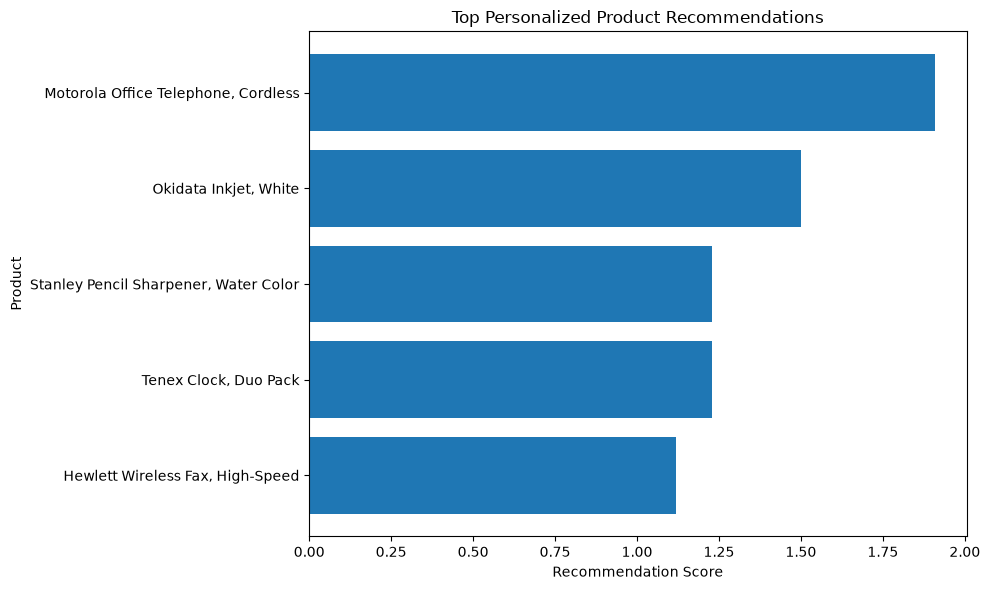

Recommendation score chart created successfully!


In [10]:
# Visualize recommendation scores

plt.figure(figsize=(10, 6))

plt.barh(
    recommendations["product_name"][::-1],
    recommendations["recommendation_score"][::-1]
)

plt.xlabel("Recommendation Score")
plt.ylabel("Product")
plt.title("Top Personalized Product Recommendations")

plt.tight_layout()

plt.savefig("recommendation_scores.png", dpi=300)

plt.show()

print("Recommendation score chart created successfully!")

In [11]:
# Save recommendation outputs

similar_customers.to_csv(
    "similar_customer_analysis.csv",
    index=False
)

recommendations.to_csv(
    "recommendation_output.csv",
    index=False
)

# Save relevance result
relevance_summary = pd.DataFrame({
    "customer_name": [sample_customer],
    "relevance_score": [relevance_score],
    "relevance_percentage": [relevance_score * 100]
})

relevance_summary.to_csv(
    "recommendation_relevance.csv",
    index=False
)

print("Recommendation outputs saved successfully!")

print("\nFiles created:")
print("- similar_customer_analysis.csv")
print("- recommendation_output.csv")
print("- recommendation_relevance.csv")
print("- recommendation_scores.png")

Recommendation outputs saved successfully!

Files created:
- similar_customer_analysis.csv
- recommendation_output.csv
- recommendation_relevance.csv
- recommendation_scores.png


In [12]:
# Create personalization strategy document

strategy_text = f"""
# Personalized Product Recommendation Strategy

## Objective

The goal of this recommendation engine is to suggest products
based on similarities between customer purchasing behaviors.

## Recommendation Approach

1. Create a customer-product purchase matrix.
2. Calculate customer similarity using cosine similarity.
3. Identify the most similar customers.
4. Collect products purchased by similar customers.
5. Remove products already purchased by the target customer.
6. Rank the remaining products using recommendation scores.
7. Evaluate recommendation relevance using product categories
   and sub-categories.

## Personalization Strategy

Customers with similar purchasing patterns can receive
similar product suggestions.

This approach can help businesses:

- Improve product discovery
- Provide personalized suggestions
- Increase customer engagement
- Support cross-selling opportunities
- Understand customer purchasing behavior

## Evaluation

Recommendation relevance is measured using category and
sub-category overlap with the customer's previous purchases.

Sample customer:
{sample_customer}

Recommendation relevance:
{relevance_score * 100:.2f}%

## Key Takeaway

Customer behavior and similarity can be used to create
personalized product recommendations.
"""

with open("recommendation_strategy.md", "w", encoding="utf-8") as file:
    file.write(strategy_text)

print("Personalization strategy document created successfully!")

Personalization strategy document created successfully!


In [13]:
# Check Day 32 output files

import os

files_to_check = [
    "day32.ipynb",
    "similar_customer_analysis.csv",
    "recommendation_output.csv",
    "recommendation_relevance.csv",
    "recommendation_scores.png",
    "recommendation_strategy.md",
    "README.md"
]

print("Day 32 file check:\n")

for file in files_to_check:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "- NOT FOUND")

print("\nDay 32 file check completed!")

Day 32 file check:

✓ day32.ipynb
✓ similar_customer_analysis.csv
✓ recommendation_output.csv
✓ recommendation_relevance.csv
✓ recommendation_scores.png
✓ recommendation_strategy.md
✓ README.md

Day 32 file check completed!
